In [2]:
import numpy as np
import pandas as pd
import multiprocessing as mp
from inspect import signature
from matplotlib import pyplot as plt
from dacbench.logger import Logger, log2dataframe, load_logs
import seaborn as sns
import glob
from plotting import plot_performance_over_time, plot_final_performance_comparison, plot_improvement_probability, plot_configuration_footprint, plot_hp_importance, plot_deepcave
#from plotting import plot_performance_over_time, plot_final_performance_comparison, plot_improvement_probability, plot_configuration_footprint, plot_hp_importance, plot_deepcave

In [17]:
import json
import glob
import pandas as pd
from typing import List

def extract_metric_all_seeds(trainer_state_paths: List[str],
                             seeds: List[int],
                             metric_key: str,
                             method: str) -> pd.DataFrame:
    """
    Given multiple trainer_state.json file paths (one per seed), extract a chosen metric
    (e.g., 'train_perplexity' or 'eval_perplexity') from each file and combine them into
    a single DataFrame with columns: ['step', 'seed', 'value', 'method'].
    """
    if len(trainer_state_paths) != len(seeds):
        raise ValueError("The number of trainer_state paths must match the number of seeds.")

    df_list = []
    for path, seed in zip(trainer_state_paths, seeds):
        with open(path, "r") as f:
            trainer_state = json.load(f)

        data_for_this_seed = []
        for log_entry in trainer_state.get("log_history", []):
            # Only include entries that have both the metric and a 'step'
            if metric_key in log_entry and "step" in log_entry:
                data_for_this_seed.append({
                    "step": log_entry["step"],
                    "seed": seed,
                    "value": log_entry[metric_key],
                    "method": method
                })

        if data_for_this_seed:
            df_list.append(pd.DataFrame(data_for_this_seed))

    if df_list:
        return pd.concat(df_list, ignore_index=True)
    else:
        # Return an empty DataFrame with the expected columns if no data is found.
        return pd.DataFrame(columns=["step", "seed", "value", "method"])

def extract_metric_from_parent_dir(parent_dir: str,
                                   metric_key: str,
                                   method: str) -> pd.DataFrame:
    """
    Searches for all trainer_state.json files within the subdirectories of the given parent directory,
    using a glob pattern that matches the structure:
    
        parent_dir/seed_*/results/*/trainer_state.json
    
    Seeds are automatically assigned based on the sorted order of the files.
    
    :param parent_dir: The parent directory for the method (e.g. "./COCOB_roberta_bookwiki")
    :param metric_key: The metric key to extract (e.g., "train_perplexity" or "eval_perplexity")
    :param method: The method/optimizer name (e.g., "COCOB", "DAdaptAdam", etc.)
    :return: A pandas DataFrame with columns ['step', 'seed', 'value', 'method'].
    """
    # Create the glob pattern to find trainer_state.json files
    pattern = f"{parent_dir}/seed_*/results/*/trainer_state.json"
    trainer_state_paths = sorted(glob.glob(pattern))
    
    # Automatically assign seed values based on the sorted order
    # Alternatively, you could parse the seed number from the folder name.
    seeds = list(range(1, len(trainer_state_paths) + 1))
    
    return extract_metric_all_seeds(trainer_state_paths, seeds, metric_key, method)


def downsample_data(df, bin_size=50):
    # Create a new column for the bin index based on the step
    df['step'] = (df['step'] // bin_size) * bin_size
    # Group by method and bin, then compute the mean value and standard error
    grouped = df.groupby(['method', 'seed', 'step'])['value'].mean().reset_index()
    return grouped



sns.set(rc={"figure.dpi":300, 'savefig.dpi':300})
sns.set_style('whitegrid')
palette = sns.color_palette("colorblind")
palette = sns.color_palette([palette[0], palette[2], palette[1], palette[3], palette[4], palette[5]])
sns.set_palette(palette)

          method  seed   step         value
0     Adam Fixed     1      0  17918.049010
1     Adam Fixed     1    100      5.714730
2     Adam Fixed     1    200      1.015765
3     Adam Fixed     1    300      1.004541
4     Adam Fixed     1    400      1.002043
...          ...   ...    ...           ...
2265     Prodigy     2  22600      1.000000
2266     Prodigy     2  22700      1.000000
2267     Prodigy     2  22800      1.000000
2268     Prodigy     2  22900      1.000000
2269     Prodigy     2  23000      1.000000

[2270 rows x 4 columns]


/home/micha/Studium/BA_new/BA-Parameter-Free-DAC/ba_parameter_free_dac/plotting/plotting.py:205: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax = sns.lineplot(data=data, x=x, y=y, ax=ax, marker=marker, hue=hue, errorbar=errorbar, estimator=aggregation,palette=sns.color_palette('colorblind', as_cmap = True))
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seabor

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


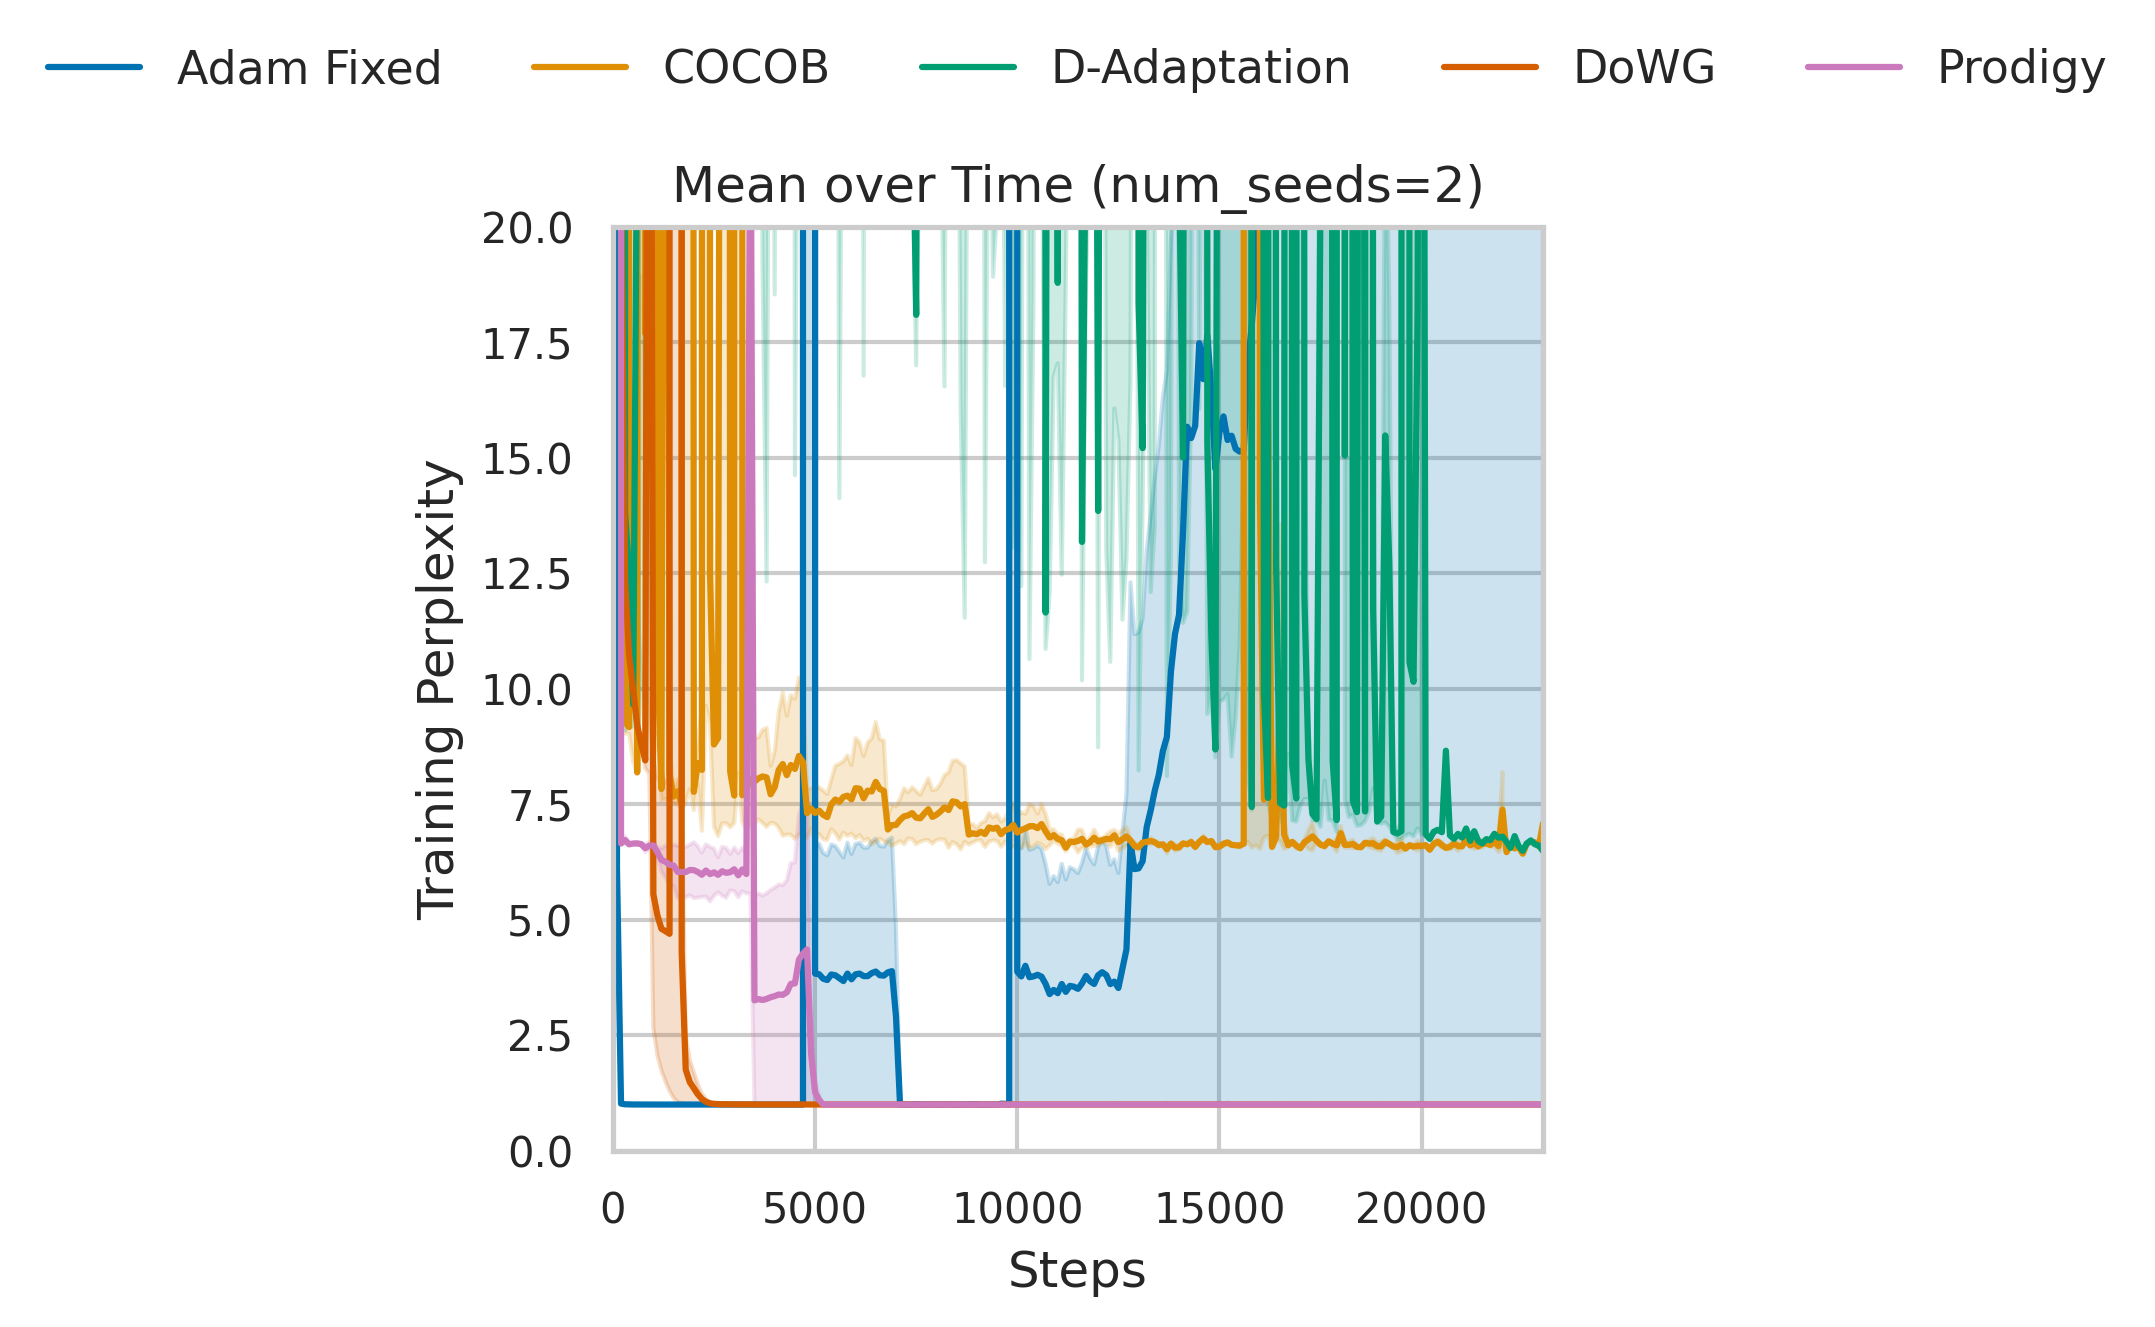

In [30]:
adamfixed_tp = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/Adam_fixed_roberta_bookwiki",
    metric_key="train_perplexity",
    method="Adam Fixed"
)

cocob_tp = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/COCOB_roberta_bookwiki",
    metric_key="train_perplexity",
    method="COCOB"
)

dadaptation_tp = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/DAdaptAdam_roberta_bookwiki",
    metric_key="train_perplexity",
    method="D-Adaptation"
)

dowg_tp = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/DoWG_roberta_bookwiki",
    metric_key="train_perplexity",
    method="DoWG"
)

prodigy_tp = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/ProdigyAdam_roberta_bookwiki",
    metric_key="train_perplexity",
    method="Prodigy"
)

# Combine all training DataFrames:
df_train_all = pd.concat([cocob_tp, adamfixed_tp, dowg_tp, prodigy_tp, dadaptation_tp], ignore_index=True)
df_train_all = downsample_data(df_train_all, bin_size=100)
print(df_train_all)
desired_order = ["Adam Fixed", "COCOB", "D-Adaptation", "DoWG", "Prodigy"]
df_train_all["method"] = pd.Categorical(df_train_all["method"], categories=desired_order, ordered=True)
plot_performance_over_time(
    df_train_all,
    x="step",
    y="value",
    hue="method",
    aggregation="mean",
    logx=False,
    xlabel="Steps",
    ylabel="Training Perplexity",
    ylim=(0, 20)  # Adjust as needed
)

       step  seed       value        method
0        50     1   52.749508         COCOB
1       100     1    5.611199         COCOB
2       150     1  279.733337         COCOB
3       200     1   18.162785         COCOB
4       250     1    7.412918         COCOB
...     ...   ...         ...           ...
4515  22800     2    6.512073  D-Adaptation
4516  22850     2    6.504195  D-Adaptation
4517  22900     2    6.502705  D-Adaptation
4518  22950     2    6.499196  D-Adaptation
4519  23000     2    6.496538  D-Adaptation

[4520 rows x 4 columns]


/home/micha/Studium/BA_new/BA-Parameter-Free-DAC/ba_parameter_free_dac/plotting/plotting.py:205: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax = sns.lineplot(data=data, x=x, y=y, ax=ax, marker=marker, hue=hue, errorbar=errorbar, estimator=aggregation,palette=sns.color_palette('colorblind', as_cmap = True))
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seabor

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


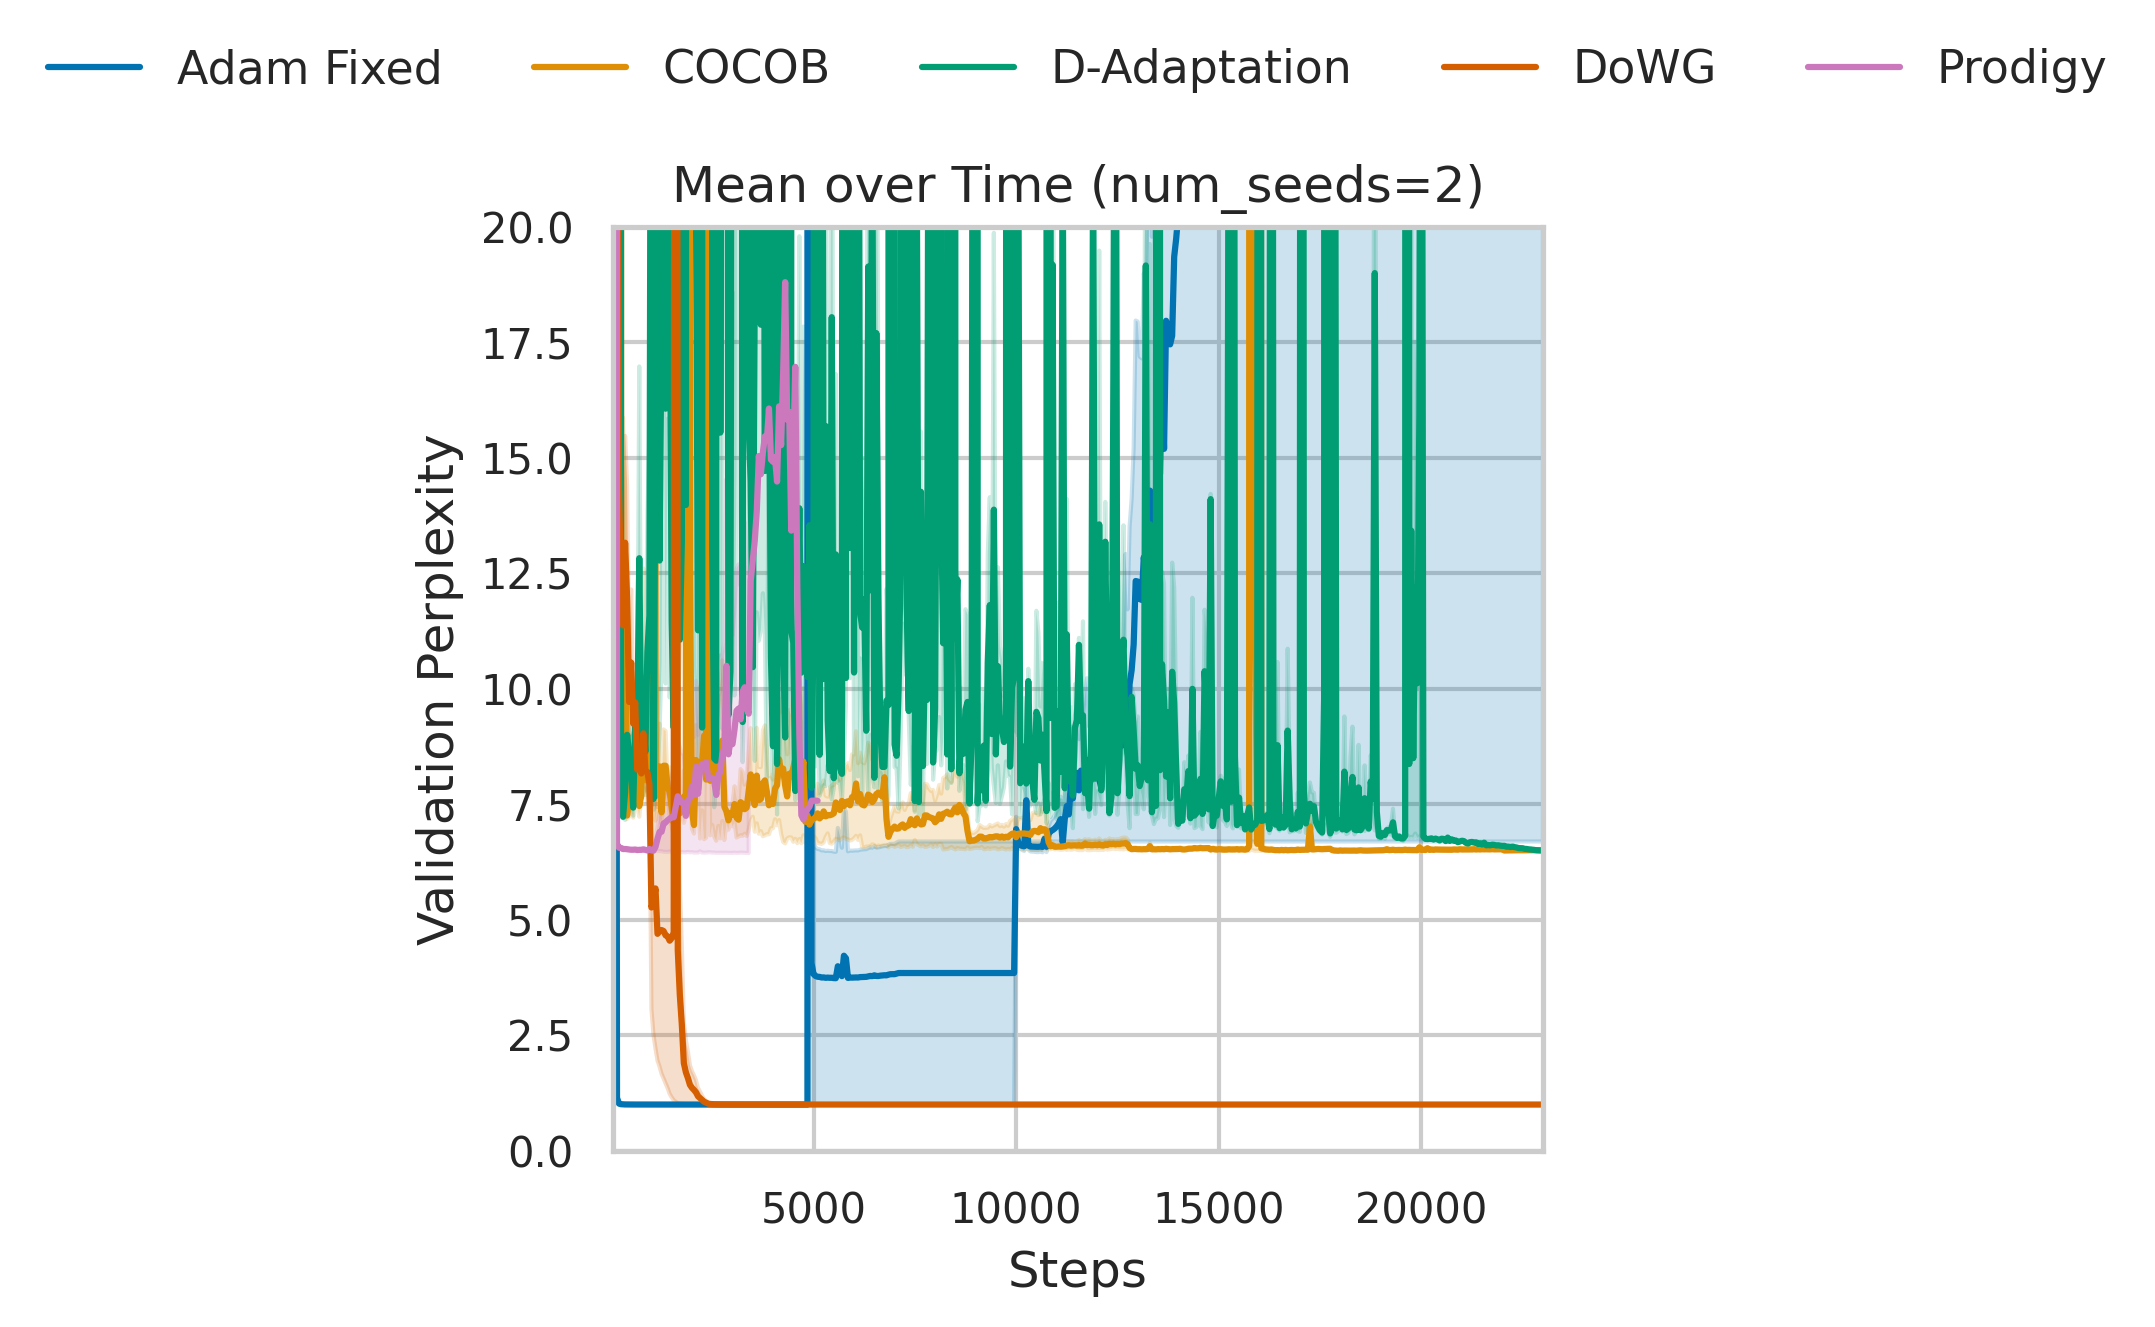

In [31]:
adamfixed_ep = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/Adam_fixed_roberta_bookwiki",
    metric_key="eval_perplexity",
    method="Adam Fixed"
)

cocob_ep = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/COCOB_roberta_bookwiki",
    metric_key="eval_perplexity",
    method="COCOB"
)

dadaptation_ep = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/DAdaptAdam_roberta_bookwiki",
    metric_key="eval_perplexity",
    method="D-Adaptation"
)

dowg_ep = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/DoWG_roberta_bookwiki",
    metric_key="eval_perplexity",
    method="DoWG"
)

prodigy_ep = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/ProdigyAdam_roberta_bookwiki",
    metric_key="eval_perplexity",
    method="Prodigy"
)


# Combine all training DataFrames:
df_eval_all = pd.concat([cocob_ep, adamfixed_ep, dowg_ep, prodigy_ep, dadaptation_ep], ignore_index=True)
df_eval_all["method"] = pd.Categorical(df_eval_all["method"], categories=desired_order, ordered=True)
print(df_eval_all)
plot_performance_over_time(
    df_eval_all,
    x="step",
    y="value",
    hue="method",
    aggregation="mean",
    logx=False,
    xlabel="Steps",
    ylabel="Validation Perplexity",
    ylim=(0, 20)  # Adjust as needed
)

/home/micha/Studium/BA_new/BA-Parameter-Free-DAC/ba_parameter_free_dac/plotting/plotting.py:200: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax = sns.lineplot(data=data, x=x, y=y, ax=ax, marker=marker, hue=hue, errorbar=errorbar, estimator=aggregation,palette=sns.color_palette('colorblind', as_cmap = True))
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/micha/Studium/BA_new/BA-Parameter-Free-DAC/ba_parameter_free_d

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [135, 135, 135],
        [ 38,  38,  38]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


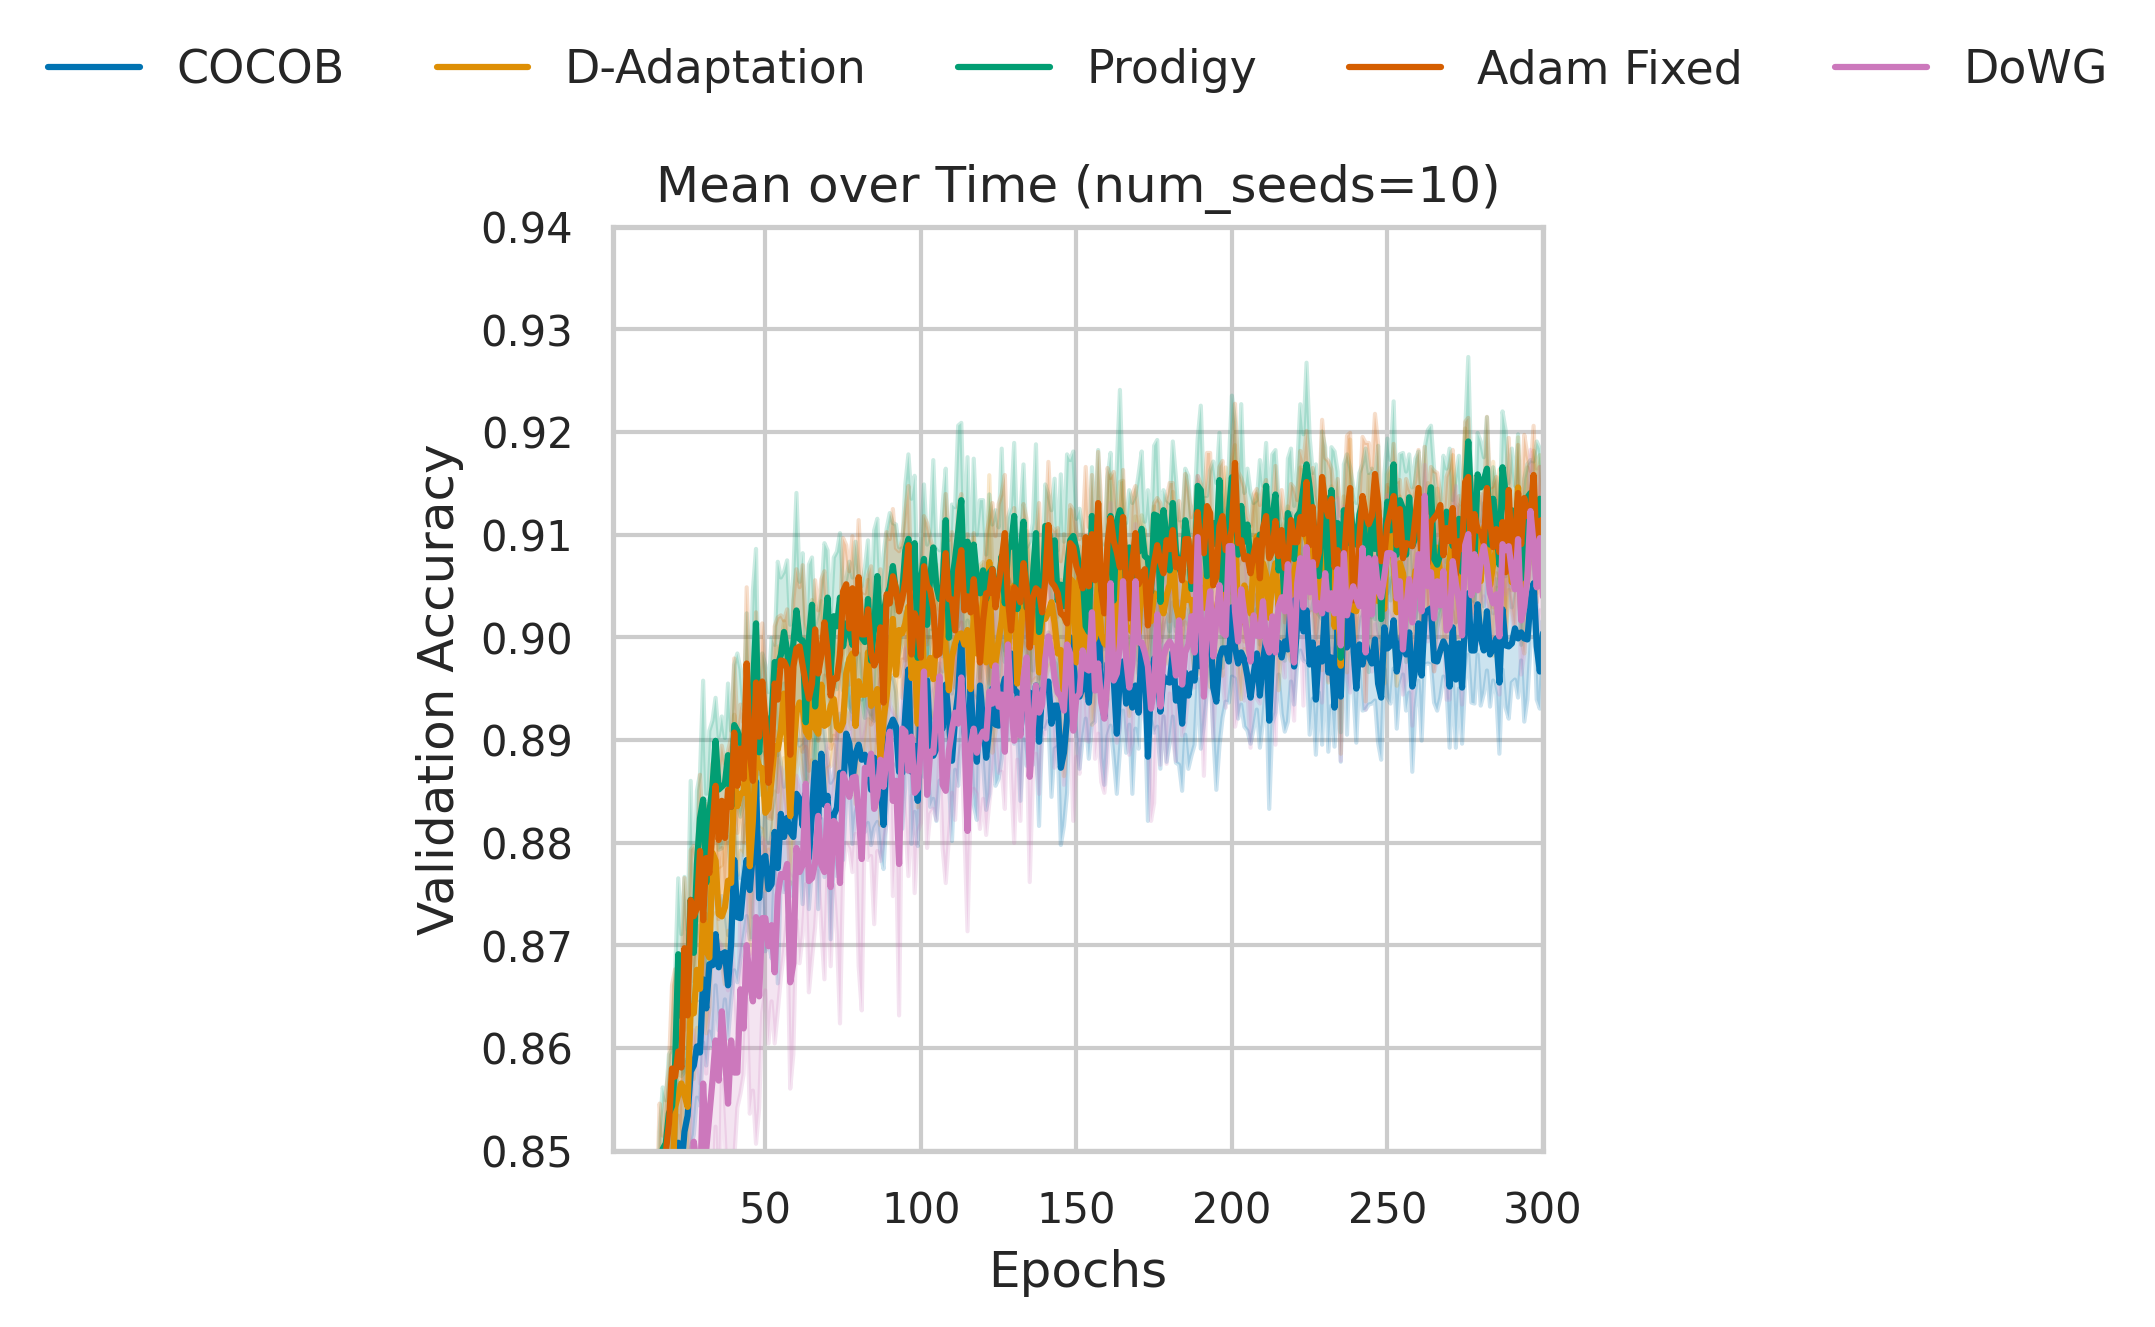

In [7]:
cocob_tl = toDataFrame('../results_cluster/results/COCOB_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6, method='COCOB')
dadaptation_tl = toDataFrame('../results_cluster/results/dadaptation_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6, method='D-Adaptation')
prodigy_tl = toDataFrame('../results_cluster/results/prodigy_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6, method='Prodigy')
adam_fixed_tl = toDataFrame('../results_cluster/results/Adam_fixed_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6, 'Adam Fixed')
dowg_tl = toDataFrame('../results_cluster/results/DoWG_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6, 'DoWG')

# 'seed', 'epoch', 'method', 'training_loss'

data = pd.concat([cocob_tl, dadaptation_tl, prodigy_tl, adam_fixed_tl, dowg_tl], ignore_index=True)
plot_performance_over_time(data, x="epoch", y="value", hue="method", aggregation="mean", logx=False, xlabel="Epochs", ylabel="Validation Accuracy", ylim=(0.85,0.94))

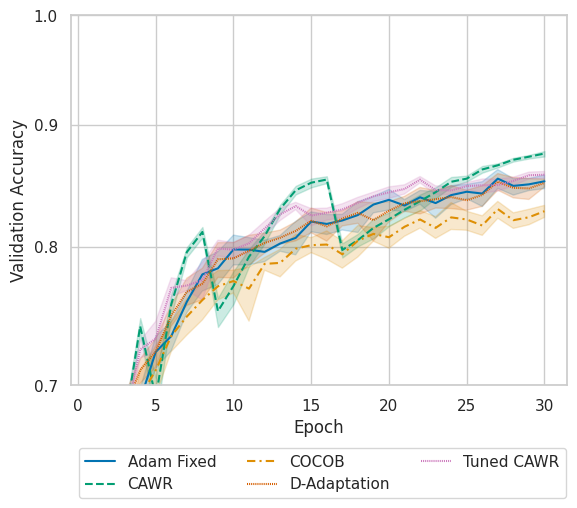

In [ ]:

cocob_va = toDataFrame('../results_cluster/results/COCOB_cifar10_30/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
adam_fixed_va = toDataFrame('../results_cluster/results/Adam_fixed_cifar10_30/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
smac_fixed_va = toDataFrame('../results_cluster/results/SMAC_fixed_cifar10_30/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
stormplus_va = toDataFrame('../results_cluster/results/STORMplus_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
# smac_fixed_va = smac_fixed_va.loc[smac_fixed_va['epoch'] <= 30]
smac_policy_va = toDataFrame('../results_cluster/results/smacpolicy_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
smac_policy_va_new = toDataFrame('../results_cluster/results/smacpolicy_cifar10_new/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
dowg_va = toDataFrame('../results_cluster/results/DoWG_cifar10_30/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
cawr_va = toDataFrame('../results_cluster/results/CAWR_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
tuned_cawr_va = toDataFrame('../results_cluster/results/tuned_CAWR_cifar10_1/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
dadaptation_va = toDataFrame('../results_cluster/results/dadaptation_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
# cawr_va = cawr_va.loc[cawr_va['epoch'] <= 30]
# sns.lineplot(data=stormplus_va, x='epoch', y='value', label='STORM+')
p = sns.lineplot(data=adam_fixed_va, x='epoch', y='value', label='Adam Fixed', linestyle='solid')
sns.lineplot(data=cawr_va, x='epoch', y='value', label='CAWR', linestyle="dashed")
# sns.lineplot(data=smac_fixed_va, x='epoch', y='value', label='SMAC Fixed', linestyle='dashdot')
# sns.lineplot(data=smac_policy_va, x='epoch', y='value', label='SMAC Policy', linestyle='dotted')
sns.lineplot(data=cocob_va, x='epoch', y='value', label='COCOB', dashes=(4,2,1,2))
# sns.lineplot(data=dowg_va, x='epoch', y='value', label='DoWG', dashes=(0.5, 0.5))
sns.lineplot(data=dadaptation_va, x='epoch', y='value', label='D-Adaptation', dashes=(0.5, 0.5))
sns.lineplot(data=tuned_cawr_va, x='epoch', y='value', label='Tuned CAWR', dashes=(0.5, 0.5))

plt.title('CIFAR-10')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.yscale('log')
plt.ylim(0.7, 1)
plt.yticks([0.7, 0.8, 0.9, 1], ["0.7", "0.8", "0.9", "1.0"])
sns.move_legend(p, 'upper left', bbox_to_anchor=(0, -0.15), ncol=3)

Text(0, 0.5, 'Validation Accuracy')

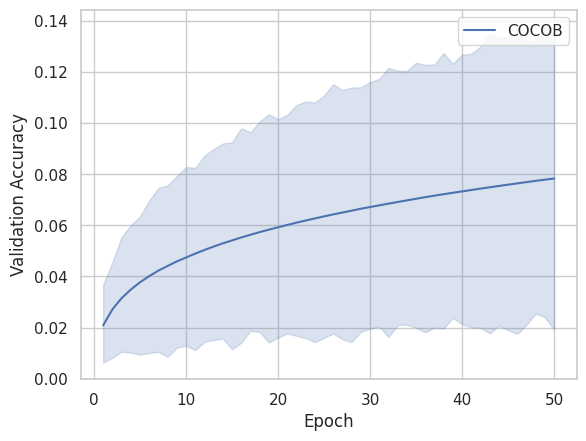

In [26]:

cocob_elr = toDataFrame('./results_cluster/results/COCOB_cifar10/*/CustomTrackingWrapper.jsonl', 'effective_lrs', 9)
sns.lineplot(data=cocob_elr, x='epoch', y='value', label='COCOB')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')